# Kaggle Datset load (Use Once)

In [75]:
# import kagglehub
# from kagglehub import KaggleDatasetAdapter

# df = kagglehub.dataset_load(
#     KaggleDatasetAdapter.PANDAS,
#     "laveshjadon/ai-impact-on-students",
#     "ai_student_impact_dataset (1).csv"
# )

# df.to_csv("ai_student_impact_dataset.csv", index=False)

## Data Ingestion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import data_profiling
import matplotlib
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, 
                            mean_absolute_percentage_error,
                            root_mean_squared_error, 
                            r2_score)
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("ai_student_impact_dataset.csv")

In [4]:
df.sample(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
12734,112735,STEM,Junior,2.545,11.14,Debugging/Troubleshooting,Advanced,3,True,12.32,2,Strict_Ban,8,3.046,73.16,Low
34114,134115,Business,Freshman,2.116,8.38,Ideation,Beginner,2,True,9.91,2,Allowed_With_Citation,1,2.339,70.48,Medium
22553,122554,Business,Junior,2.576,5.26,Debugging/Troubleshooting,Beginner,3,True,12.63,3,Allowed_With_Citation,4,3.056,76.50,Medium
16291,116292,STEM,Freshman,3.693,6.70,Debugging/Troubleshooting,Advanced,4,False,2.41,1,Strict_Ban,2,3.760,94.78,High
35410,135411,STEM,Freshman,2.972,8.05,Ideation,Beginner,3,False,9.75,4,Allowed_With_Citation,6,3.243,85.25,High
4010,104011,STEM,Senior,3.322,7.21,Copywriting/Drafting,Advanced,4,True,11.17,4,Allowed_With_Citation,6,3.325,87.49,Medium
4802,104803,Medical,Graduate,3.054,15.46,Ideation,Beginner,1,True,12.53,5,Allowed_With_Citation,3,3.599,96.33,High
34230,134231,Business,Graduate,3.265,9.45,Copywriting/Drafting,Beginner,3,False,8.84,6,Allowed_With_Citation,6,3.547,62.90,Low
4584,104585,Business,Junior,3.584,0.13,Summarizing_Reading,Advanced,3,False,5.52,2,Allowed_With_Citation,1,3.526,70.59,Medium
41701,141702,Medical,Freshman,3.886,5.50,Summarizing_Reading,Advanced,5,True,12.80,4,Actively_Encouraged,3,4.000,85.75,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
columns = df.columns

In [7]:
print(columns)

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')


In [8]:
cat_cols = df.select_dtypes(include = ['object', 'category']).columns.to_list()
num_cols = df.select_dtypes(exclude = ['object', 'category', 'bool']).columns.to_list()
bool_cols = df.select_dtypes(include = ['bool']).columns.to_list()

In [9]:
num_cols.remove("Student_ID")
print(cat_cols)
print(num_cols)
print(bool_cols)

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']
['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']
['Paid_Subscription']


In [10]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [11]:
df[cat_cols+bool_cols].describe().T

,count,unique,top,freq
Major_Category,50000,5,STEM,15059
Year_of_Study,50000,5,Junior,11045
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295
Prompt_Engineering_Skill,50000,3,Beginner,18495
Institutional_Policy,50000,3,Allowed_With_Citation,25224
Burnout_Risk_Level,50000,3,Medium,21144
Paid_Subscription,50000,2,False,28846


In [12]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

## Data Profiling (Use Once)

In [88]:
# data_profile = data_profiling.ProfileReport(df, title="AI Students Dataset Profiling Report", explorative=True)
# data_profile.to_file("ai_students_data_profile.html")

## Outlier & Distribution Analysis

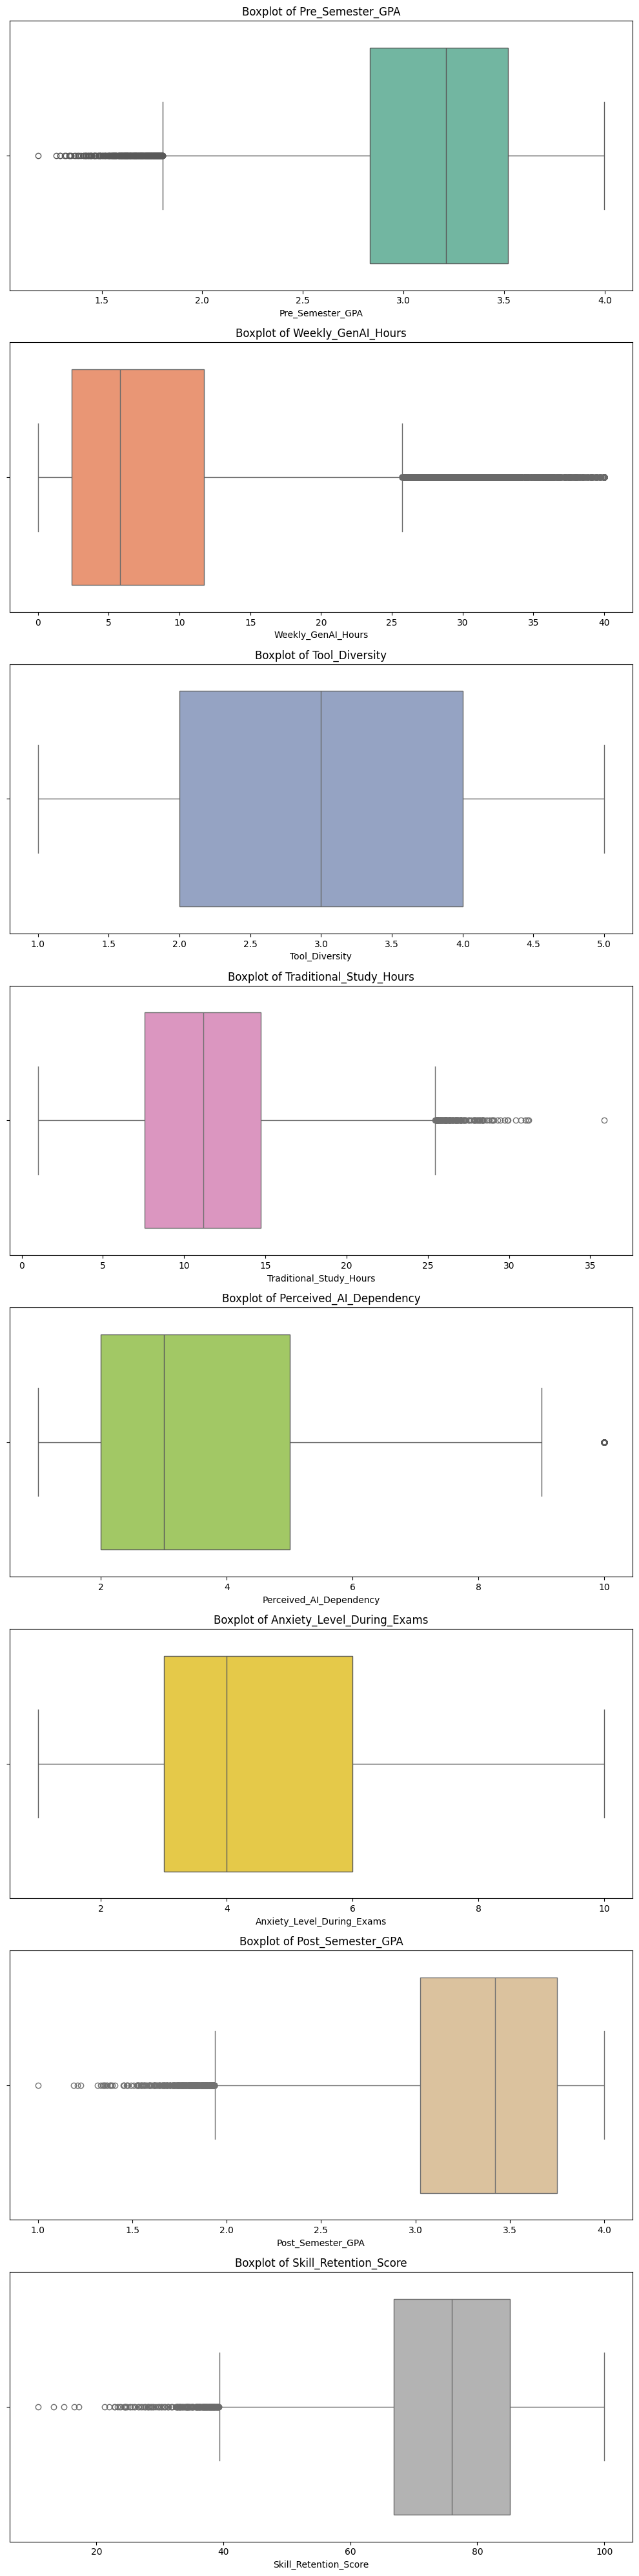

In [13]:
%matplotlib inline
palette = sns.color_palette("Set2", len(columns))
def plot_outliers(df, columns: list):
    fig, axs = plt.subplots(len(columns), figsize = (10, 5*len(columns)))
    if len(columns) == 1:
        axs = [axs]
    for ax, col, color in zip(axs,columns, palette):
        sns.boxplot(data = df, x = col, ax=ax, fill= True, color = color)
        ax.set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.savefig("ai_students_boxplots.pdf")
    plt.show();

plot_outliers(df, num_cols)

In [14]:
df[df["Traditional_Study_Hours"] > 32]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
20110,120111,Medical,Freshman,3.038,0.09,Ideation,Beginner,3,True,35.86,3,Allowed_With_Citation,5,3.753,73.13,Low


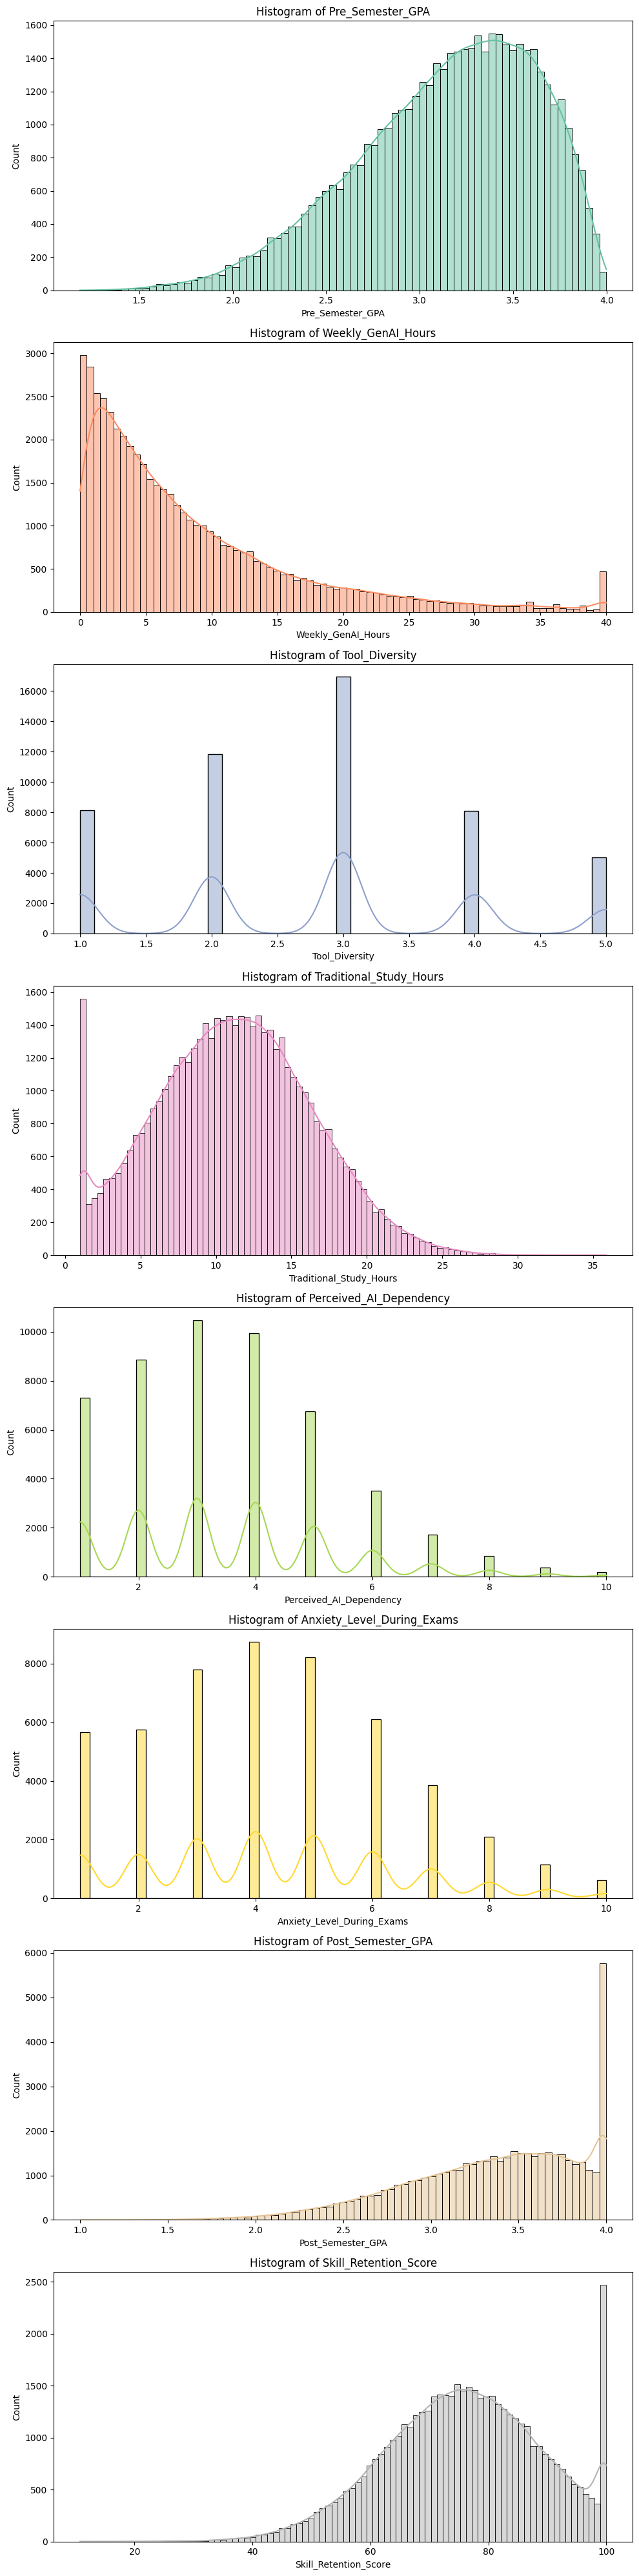

In [15]:
def hist(df, columns: list):
    fig, axs = plt.subplots(len(columns), figsize = (10,  5*len(columns)))
    if len(columns) == 1:
        axs = [axs]
    for ax, col, color in zip(axs, columns, palette):
        sns.histplot(data = df, x = col, ax = ax, kde = True, color = color)
        ax.set_title(f'Histogram of {col}')
    plt.tight_layout()
    plt.savefig("ai_students_histograms.pdf")
    plt.show();

hist(df, num_cols)

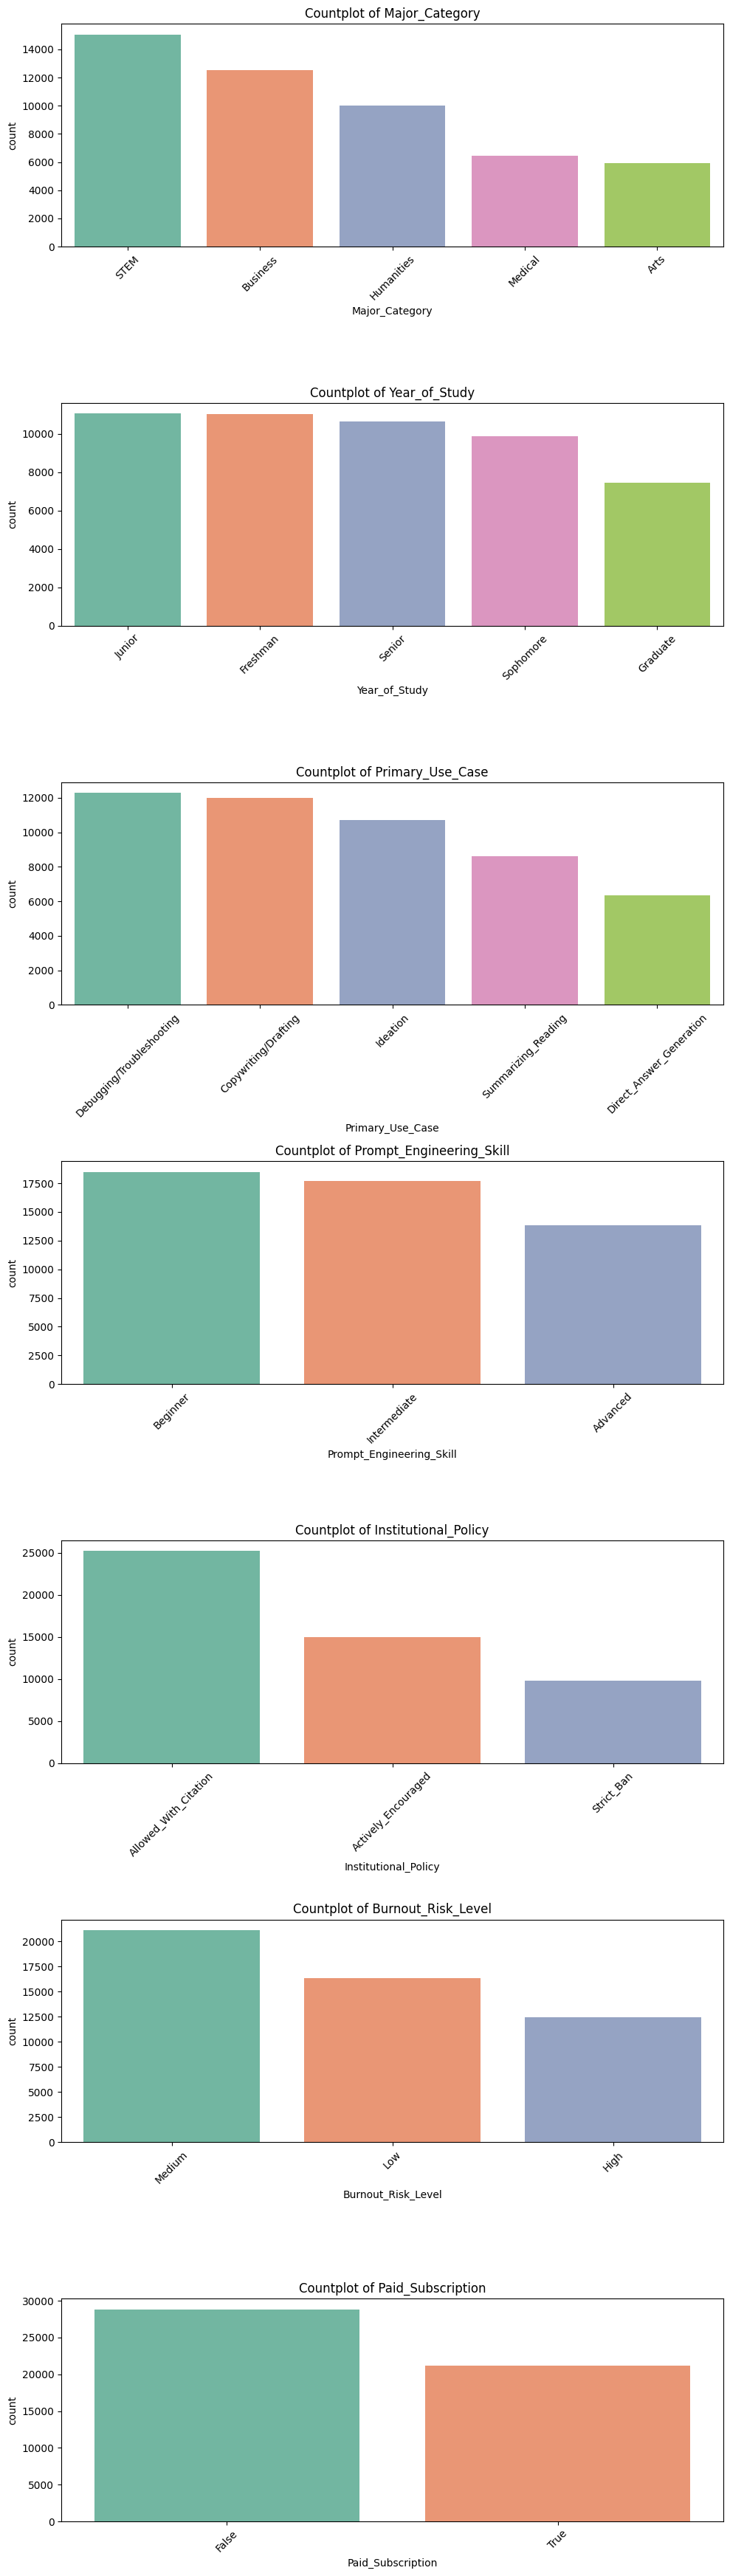

In [16]:
def countplot(df, columns: list):
    fig, axs = plt.subplots(nrows=len(columns), figsize=(10, 5*len(columns)))
    if len(columns) == 1:
        axs = [axs]
    for ax, col in zip(axs, columns):
        sns.countplot(data=df, x=col, ax=ax, palette="Set2", order=df[col].value_counts().index)
        ax.set_title(f'Countplot of {col}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig("ai_students_countplots.pdf")
    plt.show();

countplot(df, cat_cols+ bool_cols)


In [17]:
#sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha':0.5, 's':50, 'edgecolor':'k'}, height=2.5, palette=palette)
#plt.show();

## Transformation & Correlation

In [18]:
for col in cat_cols:
    print(f"========= {col} =========")
    print(df[col].unique())
    print("============================")

========= Major_Category =========
['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
========= Year_of_Study =========
['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
========= Primary_Use_Case =========
['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
========= Prompt_Engineering_Skill =========
['Beginner' 'Advanced' 'Intermediate']
========= Institutional_Policy =========
['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
========= Burnout_Risk_Level =========
['High' 'Low' 'Medium']


In [19]:
nominal_cols = ["Major_Category", "Primary_Use_Case", "Institutional_Policy"]
ordinal_cols = [col for col in cat_cols if col not in nominal_cols]

In [20]:
new_df = df.copy()

In [21]:
new_df.drop(columns=["Student_ID"], inplace=True)

In [22]:
new_df = pd.get_dummies(new_df, columns = nominal_cols, dtype = int)
new_df[bool_cols] = new_df[bool_cols].astype(int)

In [23]:
year_map = {
    "Freshman": 1,
    "Sophomore": 2,
    "Junior": 3,
    "Senior": 4,
    "Graduate": 5
}

skill_map = {
    "Beginner": 1,
    "Intermediate": 2,
    "Advanced": 3
}

burnout_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

new_df["Year_of_Study"] = new_df["Year_of_Study"].map(year_map)
new_df["Prompt_Engineering_Skill"] = new_df["Prompt_Engineering_Skill"].map(skill_map)
new_df["Burnout_Risk_Level"] = new_df["Burnout_Risk_Level"].map(burnout_map)

In [24]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year_of_Study                               50000 non-null  int64  
 1   Pre_Semester_GPA                            50000 non-null  float64
 2   Weekly_GenAI_Hours                          50000 non-null  float64
 3   Prompt_Engineering_Skill                    50000 non-null  int64  
 4   Tool_Diversity                              50000 non-null  int64  
 5   Paid_Subscription                           50000 non-null  int64  
 6   Traditional_Study_Hours                     50000 non-null  float64
 7   Perceived_AI_Dependency                     50000 non-null  int64  
 8   Anxiety_Level_During_Exams                  50000 non-null  int64  
 9   Post_Semester_GPA                           50000 non-null  float64
 10  Skill_Rete

In [25]:
new_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_of_Study,50000.0,2.871440,1.367578,1.000,2.00000,3.000,4.000,5.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Prompt_Engineering_Skill,50000.0,1.906280,0.798317,1.000,1.00000,2.000,3.000,3.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Paid_Subscription,50000.0,0.423080,0.494053,0.000,0.00000,0.000,1.000,1.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000


In [26]:
corr_matrix = new_df.corr().round(2)

corr_matrix.to_csv("ai_students_correlation_matrix.csv", index=True)

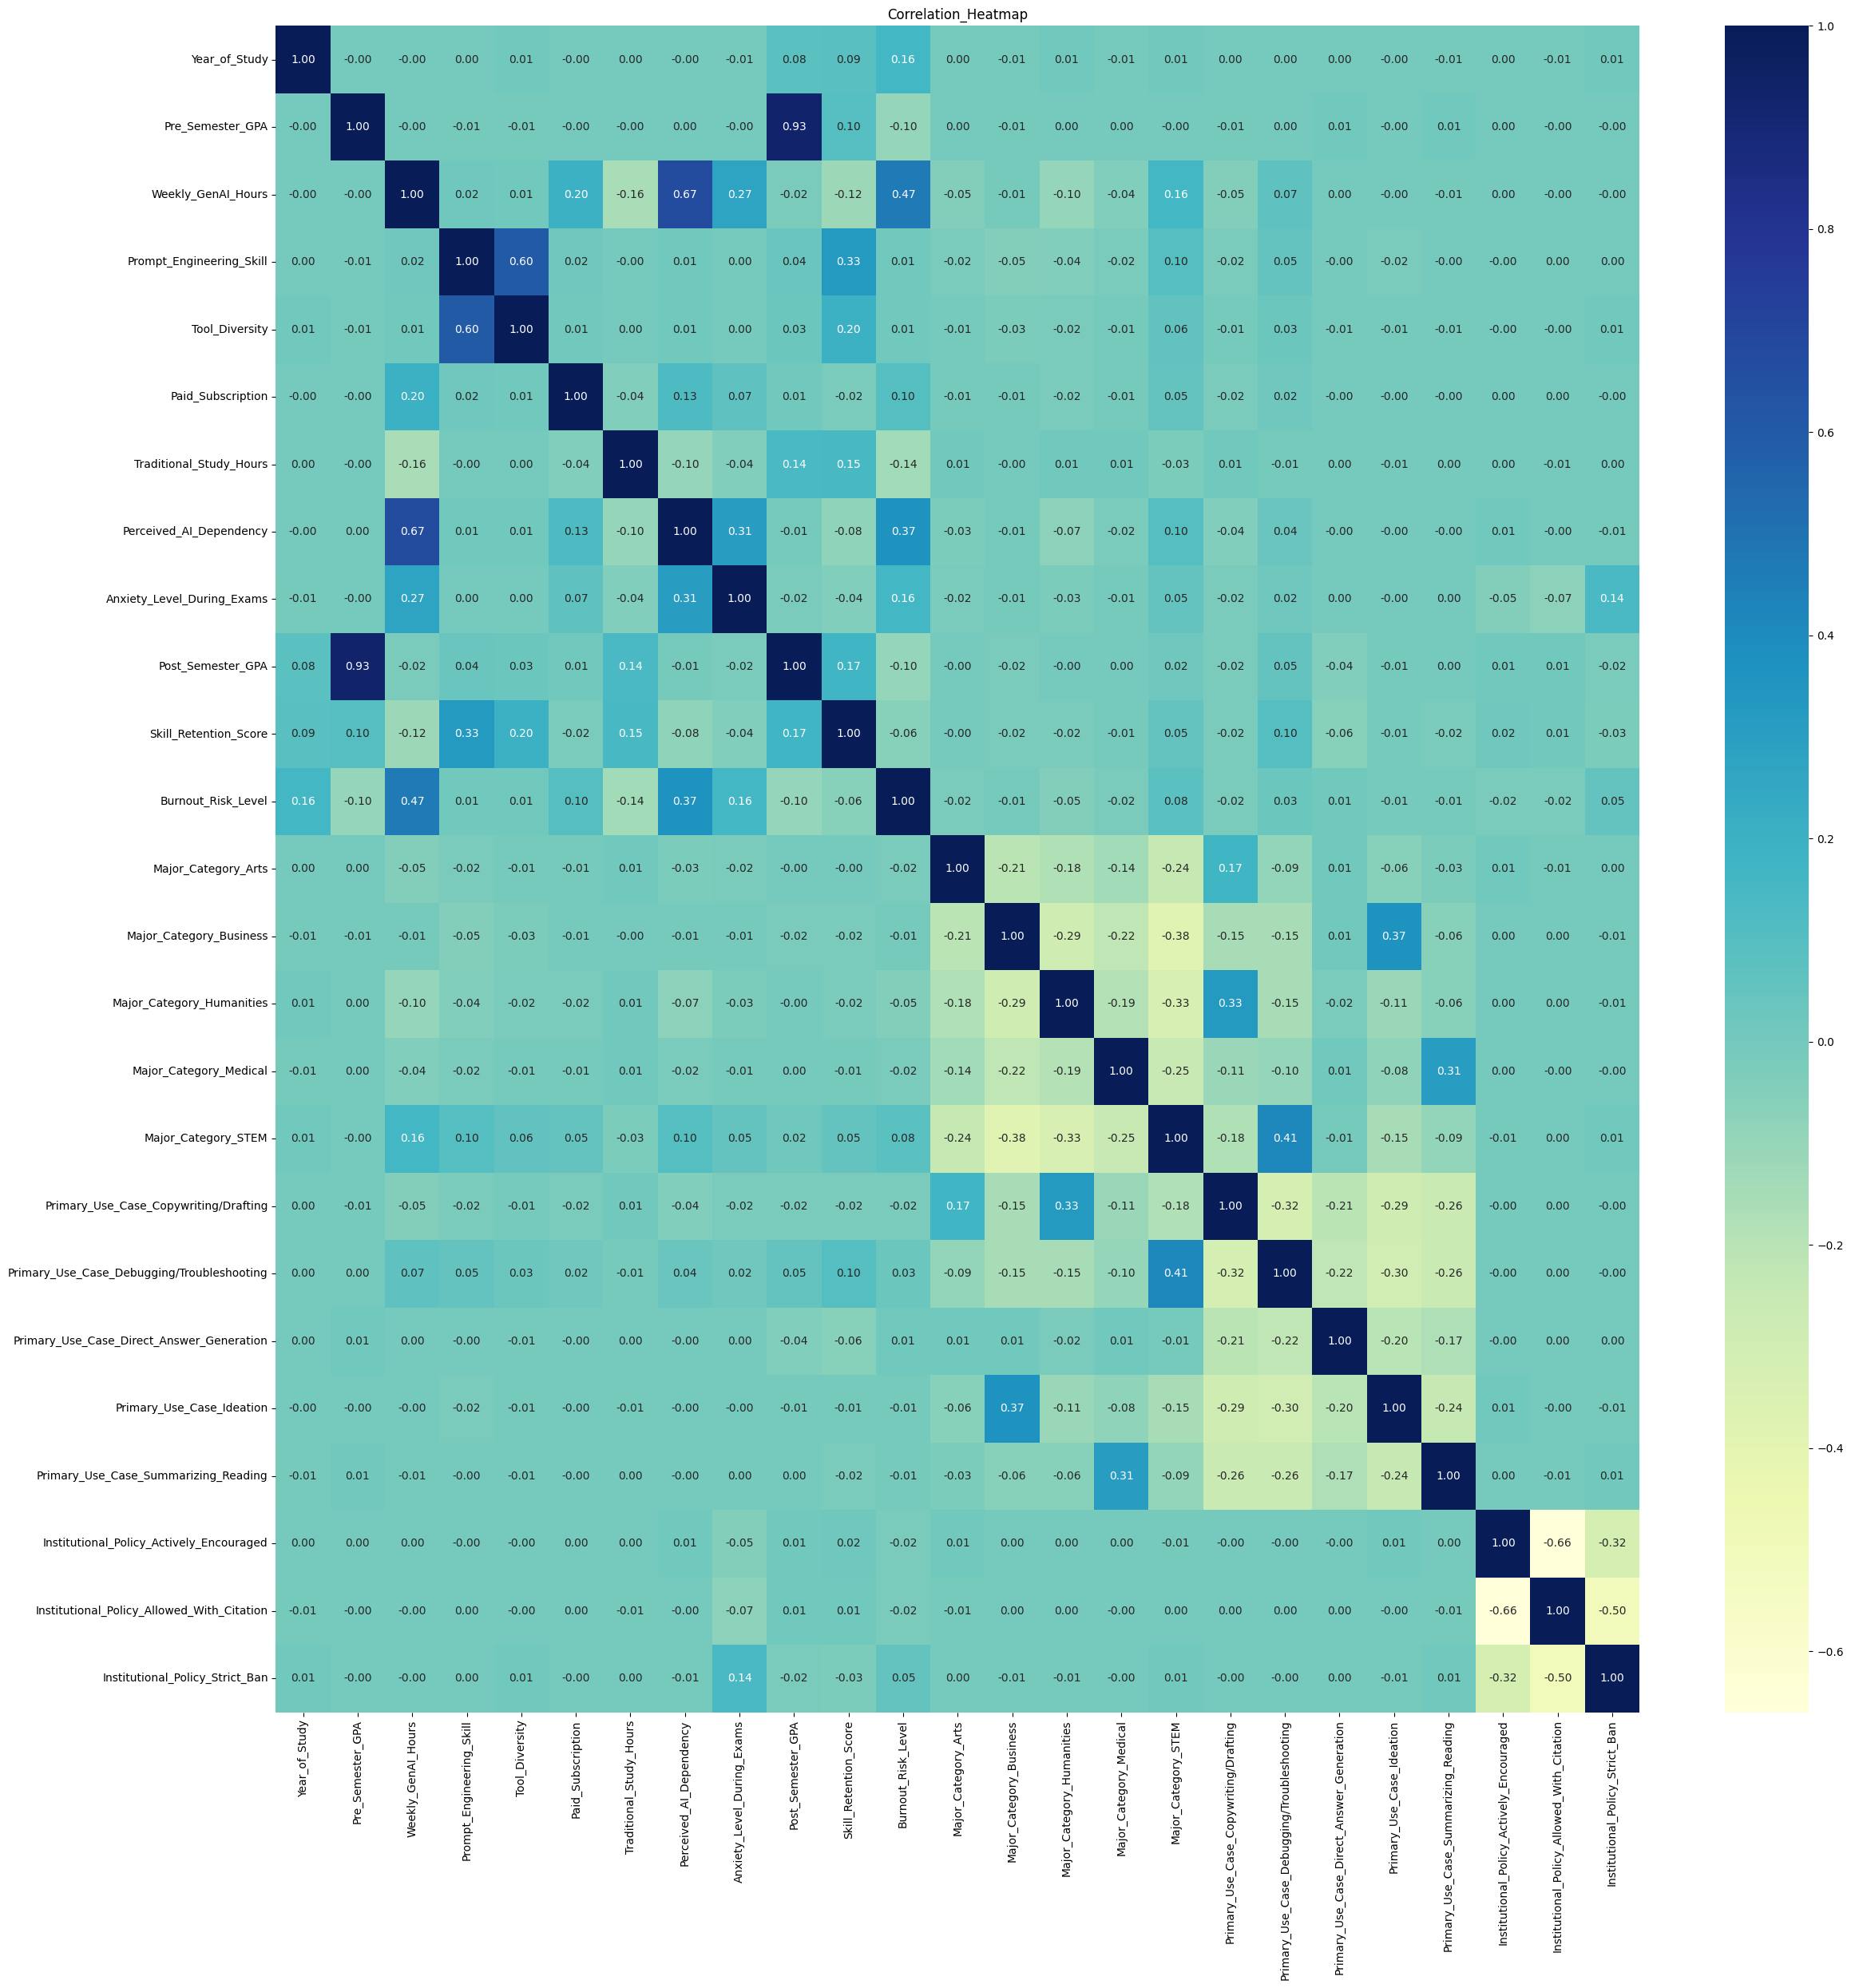

In [27]:
plt.figure(figsize = (corr_matrix.shape[1], corr_matrix.shape[1]))
sns.heatmap(corr_matrix, annot= True, fmt= ".2f", cmap= "YlGnBu")
plt.title("Correlation_Heatmap")
plt.tight_layout()
plt.savefig("ai_students_corr_heatmap.pdf")
plt.show();

In [28]:
new_df = new_df.drop(index=df.loc[df["Traditional_Study_Hours"] > 32].index)

## Post_Semester_GPA as DV (Regression Problem)

In [24]:
copy1 = new_df.copy()
copy1.columns

Index(['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Major_Category_Arts',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban'],
      dtype='object')

In [42]:
target = "Post_Semester_GPA"
cont_cols = ["Pre_Semester_GPA", 'Weekly_GenAI_Hours','Traditional_Study_Hours','Skill_Retention_Score']
count_cols = ['Tool_Diversity',]
ord_cols = [
    'Year_of_Study', 
    'Prompt_Engineering_Skill',
    'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams',
    'Burnout_Risk_Level'
    ]
binary_cols = [col for col in copy1.columns if copy1[col].nunique() == 2 and col != target]

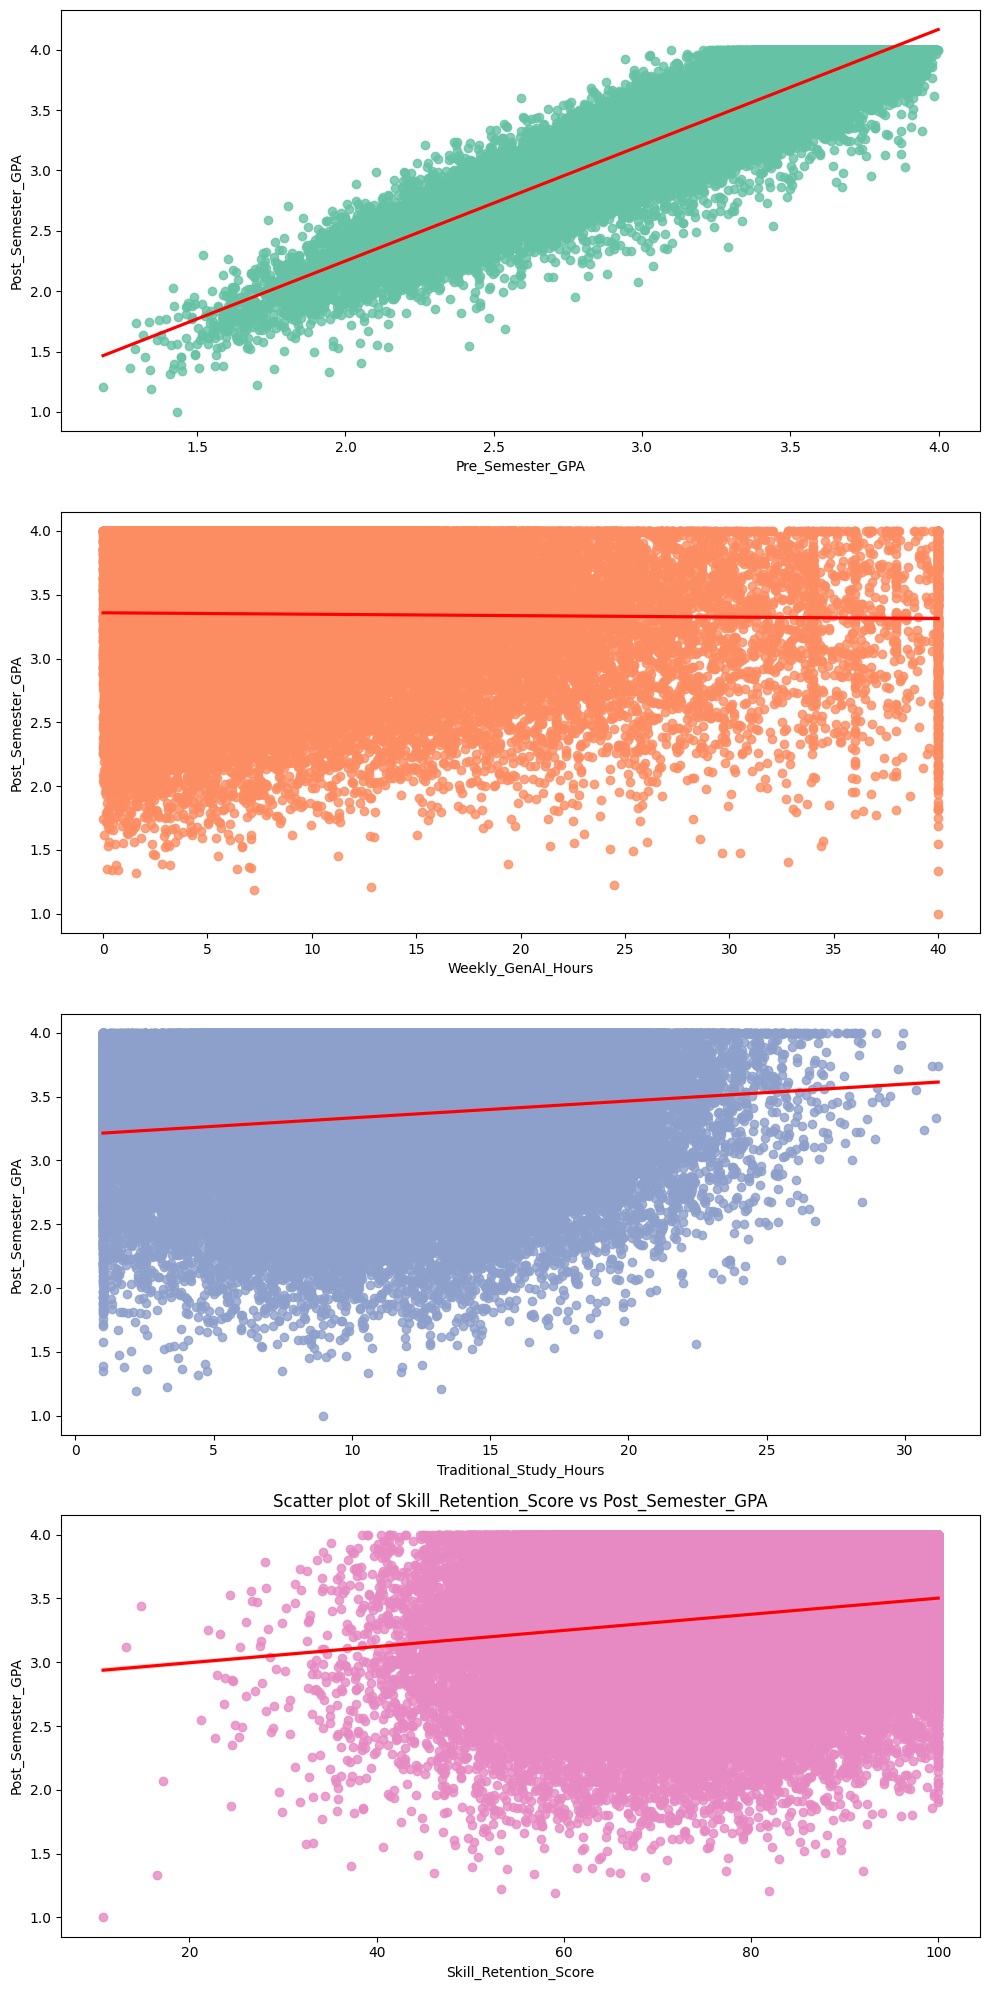

In [44]:
palette = sns.color_palette("Set2", len(columns))

fig, ax = plt.subplots(len(cont_cols), figsize=(10, 5*(len(cont_cols))))
for idx,col in enumerate(cont_cols):
    if col != target:
        sns.regplot(data = copy1, x = col, y= target, ax =ax[idx], color = palette[idx], line_kws={'color': 'red'})
        plt.title(f'Scatter plot of {col} vs Post_Semester_GPA')
plt.tight_layout()
plt.savefig("ai_students_scatterplots_dv_post_sem_gpa.pdf")
plt.show();

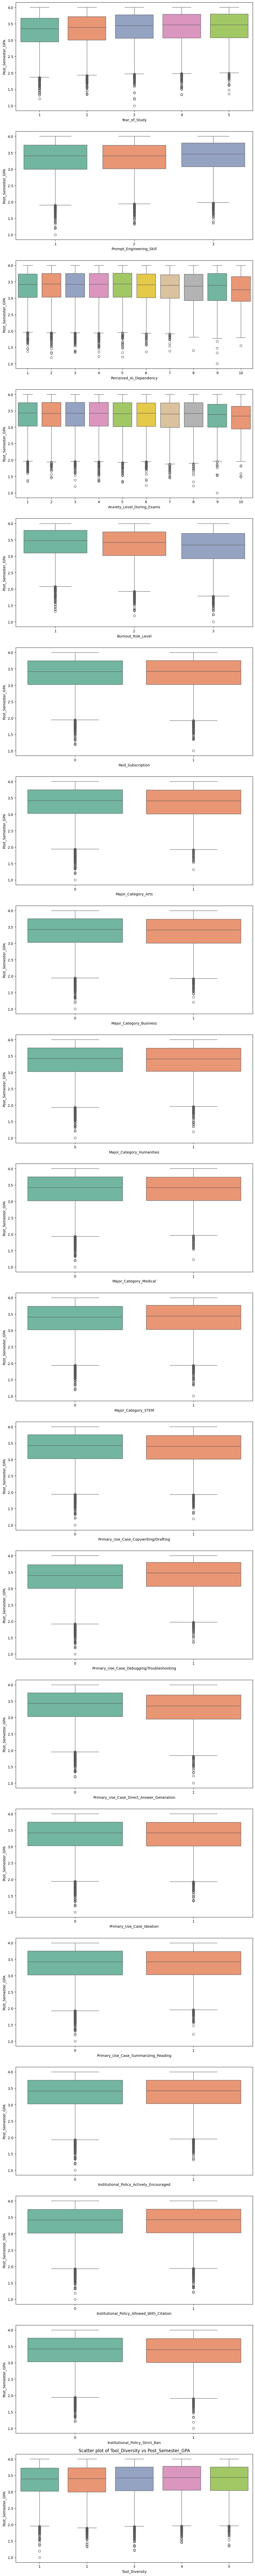

In [45]:
cat_cols = ord_cols + binary_cols + count_cols
fig, ax = plt.subplots(len(cat_cols), figsize=(10, 5*(len(cat_cols))))
for idx,col in enumerate(cat_cols):
    if col != target:
        sns.boxplot(data = copy1, x = col, y= target, ax =ax[idx], palette= palette)
        plt.title(f'Scatter plot of {col} vs Post_Semester_GPA')
plt.tight_layout()
plt.savefig("ai_students_boxplots_dv_post_sem_gpa.pdf")
plt.show();

In [46]:
new_df.shape, copy1.shape

((50000, 25), (49999, 25))

In [47]:
corr_matrix["Post_Semester_GPA"]

Year_of_Study                                 0.08
Pre_Semester_GPA                              0.93
Weekly_GenAI_Hours                           -0.02
Prompt_Engineering_Skill                      0.04
Tool_Diversity                                0.03
Paid_Subscription                             0.01
Traditional_Study_Hours                       0.14
Perceived_AI_Dependency                      -0.01
Anxiety_Level_During_Exams                   -0.02
Post_Semester_GPA                             1.00
Skill_Retention_Score                         0.17
Burnout_Risk_Level                           -0.10
Major_Category_Arts                          -0.00
Major_Category_Business                      -0.02
Major_Category_Humanities                    -0.00
Major_Category_Medical                        0.00
Major_Category_STEM                           0.02
Primary_Use_Case_Copywriting/Drafting        -0.02
Primary_Use_Case_Debugging/Troubleshooting    0.05
Primary_Use_Case_Direct_Answer_

In [48]:
copy1[cont_cols+[target]].corr()["Post_Semester_GPA"]

Pre_Semester_GPA           0.926791
Weekly_GenAI_Hours        -0.018584
Traditional_Study_Hours    0.137608
Skill_Retention_Score      0.169620
Post_Semester_GPA          1.000000
Name: Post_Semester_GPA, dtype: float64

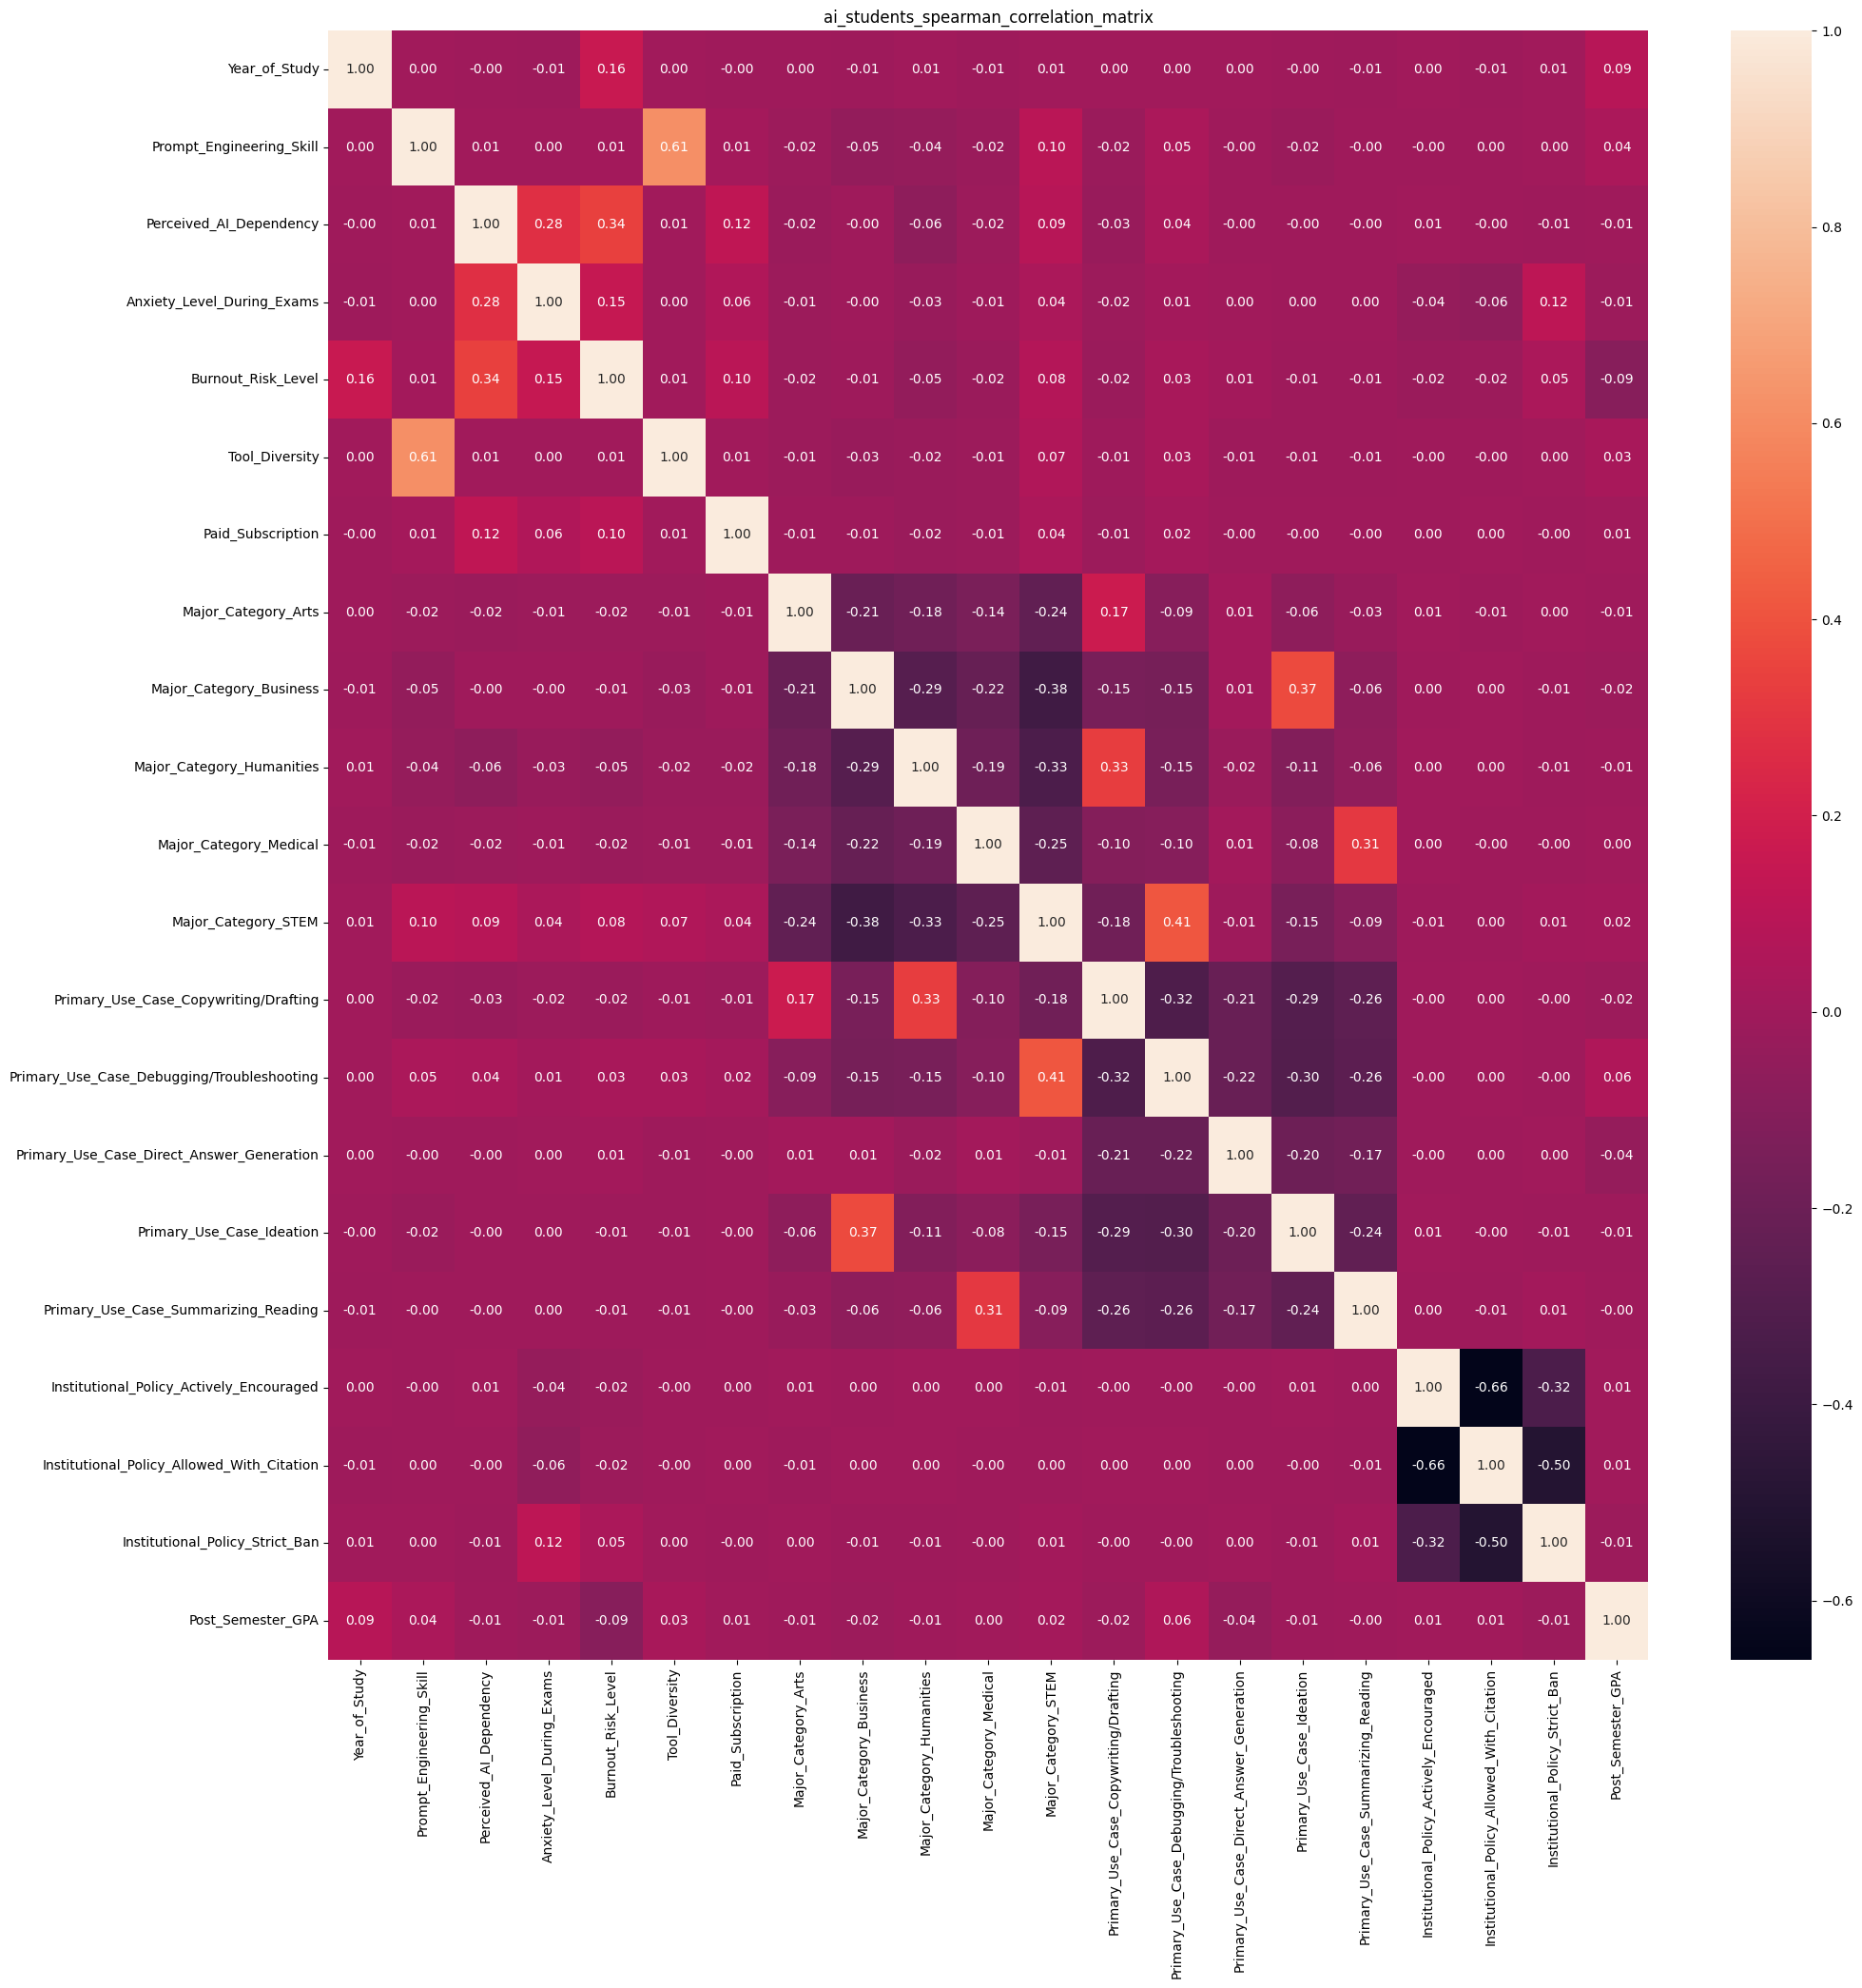

In [49]:
mat = copy1[ord_cols+count_cols+binary_cols+[target]].corr(method= "spearman",).round(3)
plt.figure(figsize= (mat.shape[1], mat.shape[1]))
sns.heatmap(mat, annot = True, fmt= ".2f")
plt.title("ai_students_spearman_correlation_matrix")
plt.tight_layout()
plt.savefig("ai_students_spearman_correlation_matrix.pdf")
plt.show();

In [50]:
copy1[ord_cols+count_cols+binary_cols+[target]].corr(method= "spearman",).round(3)[target]

Year_of_Study                                 0.087
Prompt_Engineering_Skill                      0.043
Perceived_AI_Dependency                      -0.005
Anxiety_Level_During_Exams                   -0.013
Burnout_Risk_Level                           -0.090
Tool_Diversity                                0.030
Paid_Subscription                             0.007
Major_Category_Arts                          -0.005
Major_Category_Business                      -0.016
Major_Category_Humanities                    -0.005
Major_Category_Medical                        0.003
Major_Category_STEM                           0.020
Primary_Use_Case_Copywriting/Drafting        -0.017
Primary_Use_Case_Debugging/Troubleshooting    0.056
Primary_Use_Case_Direct_Answer_Generation    -0.042
Primary_Use_Case_Ideation                    -0.007
Primary_Use_Case_Summarizing_Reading         -0.000
Institutional_Policy_Actively_Encouraged      0.006
Institutional_Policy_Allowed_With_Citation    0.007
Institutiona

In [52]:
copy1.columns

Index(['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Major_Category_Arts',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban'],
      dtype='object')

In [53]:
copy1.drop(columns = ["Major_Category_Arts", "Primary_Use_Case_Ideation", 'Institutional_Policy_Actively_Encouraged'], inplace = True)

In [25]:
X = sm.add_constant(copy1)
VIF = pd.DataFrame()

VIF['Features'] = X.columns
VIF['VIF'] = [vif(X.values, i) for i in range(X.shape[1])]
VIF.sort_values(by = 'VIF', ascending = True)

,Features,VIF
0,const,0.000000
6,Paid_Subscription,1.042266
1,Year_of_Study,1.115500
9,Anxiety_Level_During_Exams,1.141379
11,Skill_Retention_Score,1.212805
7,Traditional_Study_Hours,1.234415
12,Burnout_Risk_Level,1.368874
5,Tool_Diversity,1.569352
4,Prompt_Engineering_Skill,1.720445
8,Perceived_AI_Dependency,1.870120


In [55]:
copy1.columns

Index(['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Summarizing_Reading',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban'],
      dtype='object')

In [98]:
train_data  =  copy1.copy()
train_data.drop(columns = ['Tool_Diversity','Burnout_Risk_Level', 'Major_Category_Business',
                        'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM',
                         'Primary_Use_Case_Copywriting/Drafting', 'Primary_Use_Case_Summarizing_Reading',
                         target, 'Institutional_Policy_Allowed_With_Citation',
                        'Paid_Subscription', 'Institutional_Policy_Strict_Ban', 'Skill_Retention_Score'], inplace =True)
train_data["Depending_Hours"] = (train_data.Weekly_GenAI_Hours - train_data.Weekly_GenAI_Hours.mean()) * (train_data.Perceived_AI_Dependency - train_data.Perceived_AI_Dependency.mean())
target_data = copy1[target].copy()

In [99]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(train_data)

scaled_data = pd.DataFrame(
    scaled_data,
    columns=train_data.columns,
    index = train_data.index
)

x_train, x_test, y_train, y_test = train_test_split(scaled_data, target_data, test_size = 0.4, shuffle= True, random_state = 42)

In [100]:
scaled_data.shape, train_data.shape

((49999, 10), (49999, 10))

In [101]:
model = sm.OLS(y_train, sm.add_constant(x_train)).fit(cov_type= 'HC3')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.615e+04
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:17:05   Log-Likelihood:                 12226.
No. Observations:               29999   AIC:                        -2.443e+04
Df Residuals:                   29988   BIC:                        -2.434e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                          3.3493      0.001   3599.665      0.000       3.347       3.351
Year_of_Study                                  0.0440      0.001     47.383      0.000       0.042       0.046
Pre_Semester_GPA                               0.4607      0.001    501.430      0.000       0.459       0.462
Weekly_GenAI_Hours                             0.0161      0.002      9.943      0.000       0.013       0.019
Prompt_Engineering_Skill                       0.0230      0.001     24.308      0.000       0.021       0.025
Traditional_Study_Hours                        0.0708      0.001     74.504      0.000       0.069       0.073
Perceived_AI_Dependency                       -0.0011      0.001     -0.908      0.364      -0.004       0.001
Anxiety_Level_During_Exams                    -0.0057      0.001     -5.696      0.000      -0.008      -0.004
Primary_Use_Case_Debugging/Troubleshooting     0.0205      0.001     21.496      0.000       0.019       0.022
Primary_Use_Case_Direct_Answer_Generation     -0.0226      0.001    -19.492      0.000      -0.025      -0.020
Depending_Hours                               -0.0194      0.002    -11.533      0.000      -0.023      -0.016
==============================================================================
Omnibus:                      428.573   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              599.299
Skew:                          -0.183   Prob(JB):                    7.31e-131
Kurtosis:                       3.588   Cond. No.                         3.02
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [ ]:

predictions = model.predict(sm.add_constant(x_test))
print("MAE is: ", mean_absolute_error(y_test, predictions))
print("MAPE is:", mean_absolute_percentage_error(y_test, predictions)*100, "%")
print("RMSE is:", root_mean_squared_error(y_test, predictions))
print("R2 Score: ", r2_score(y_test, predictions)*100, "%")
variance = np.round(np.var(y_test - predictions), 5)
print(f"Variance of the residuals: {variance}")

MAE is:  0.12626906354456413
MAPE is: 3.926156851155317 %
RMSE is: 0.16099892157270493
R2 Score:  89.42344818681613 %
Variance of the residuals: 0.02592


In [81]:
model.conf_int(alpha  = 0.04)

,0,1
const,3.347398,3.351215
Year_of_Study,0.042188,0.046001
Pre_Semester_GPA,0.458774,0.462543
Weekly_GenAI_Hours,0.012703,0.019342
Prompt_Engineering_Skill,0.021064,0.024945
Traditional_Study_Hours,0.068893,0.072794
Perceived_AI_Dependency,-0.004094,0.001082
Anxiety_Level_During_Exams,-0.006452,-0.002340
Primary_Use_Case_Debugging/Troubleshooting,0.018551,0.022467
Primary_Use_Case_Direct_Answer_Generation,-0.025002,-0.020243


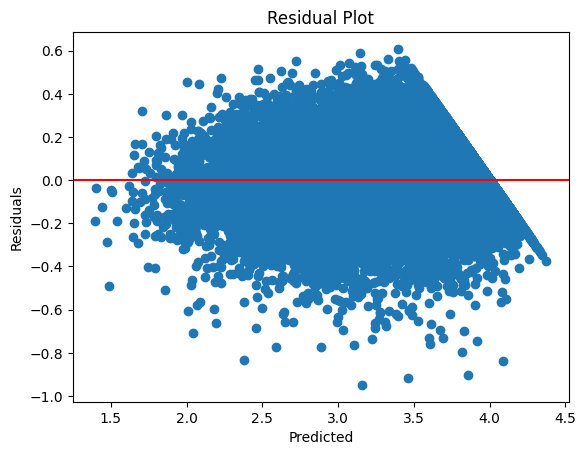

In [103]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show();

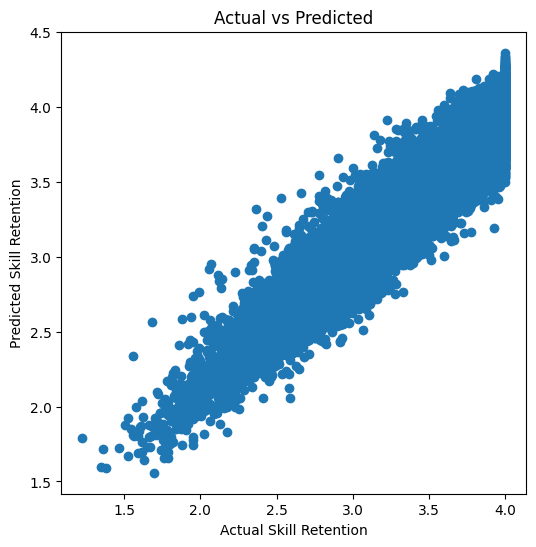

In [104]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Skill Retention")
plt.ylabel("Predicted Skill Retention")
plt.title("Actual vs Predicted")
plt.show()

In [65]:
# influence = OLSInfluence(model)
# summary = influence.summary_frame()

In [66]:
# print("Max Cook's Distance:", summary["cooks_d"].max())
# print("Max |Studentized Residual|:", summary["student_resid"].abs().max())
# print("Max Leverage:", summary["hat_diag"].max())
# print("Max |DFFITS|:", summary["dffits"].abs().max())
# print("Standardized Residuals greater than 3",(abs(summary["standard_resid"]) > 3).sum())
# outliers = summary[summary["student_resid"].abs() > 3]
# out = copy1.loc[outliers.index]
# out['GPA_Change'] = out.Post_Semester_GPA - out.Pre_Semester_GPA
# print(out.GPA_Change.describe())
# out.GPA_Change.hist()

In [ ]:
# from joblib import dump

# dump(scaler, r"D:\VSProjects\Ai_impact_on_students\models\Regression\scaler.joblib")
# model.save(r"D:\VSProjects\Ai_impact_on_students\models\Regression\ols_model.pickle")  

* This model is constantly having issues of heteroescadicity. Might be that predictors are having somewhat non-linear relation. 
* Other reason could be ceiling/floor effect meaning gaps to cover for each student is changing the variance.

### Need to check if any interactions are working

* One interaction is working fine which is Weekly_GenAi_Hours * Perceived_AI_Dependency

## Burnout_Risk_Level as DV (Classification Problem)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, RocCurveDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
cls_target = "Burnout_Risk_Level"

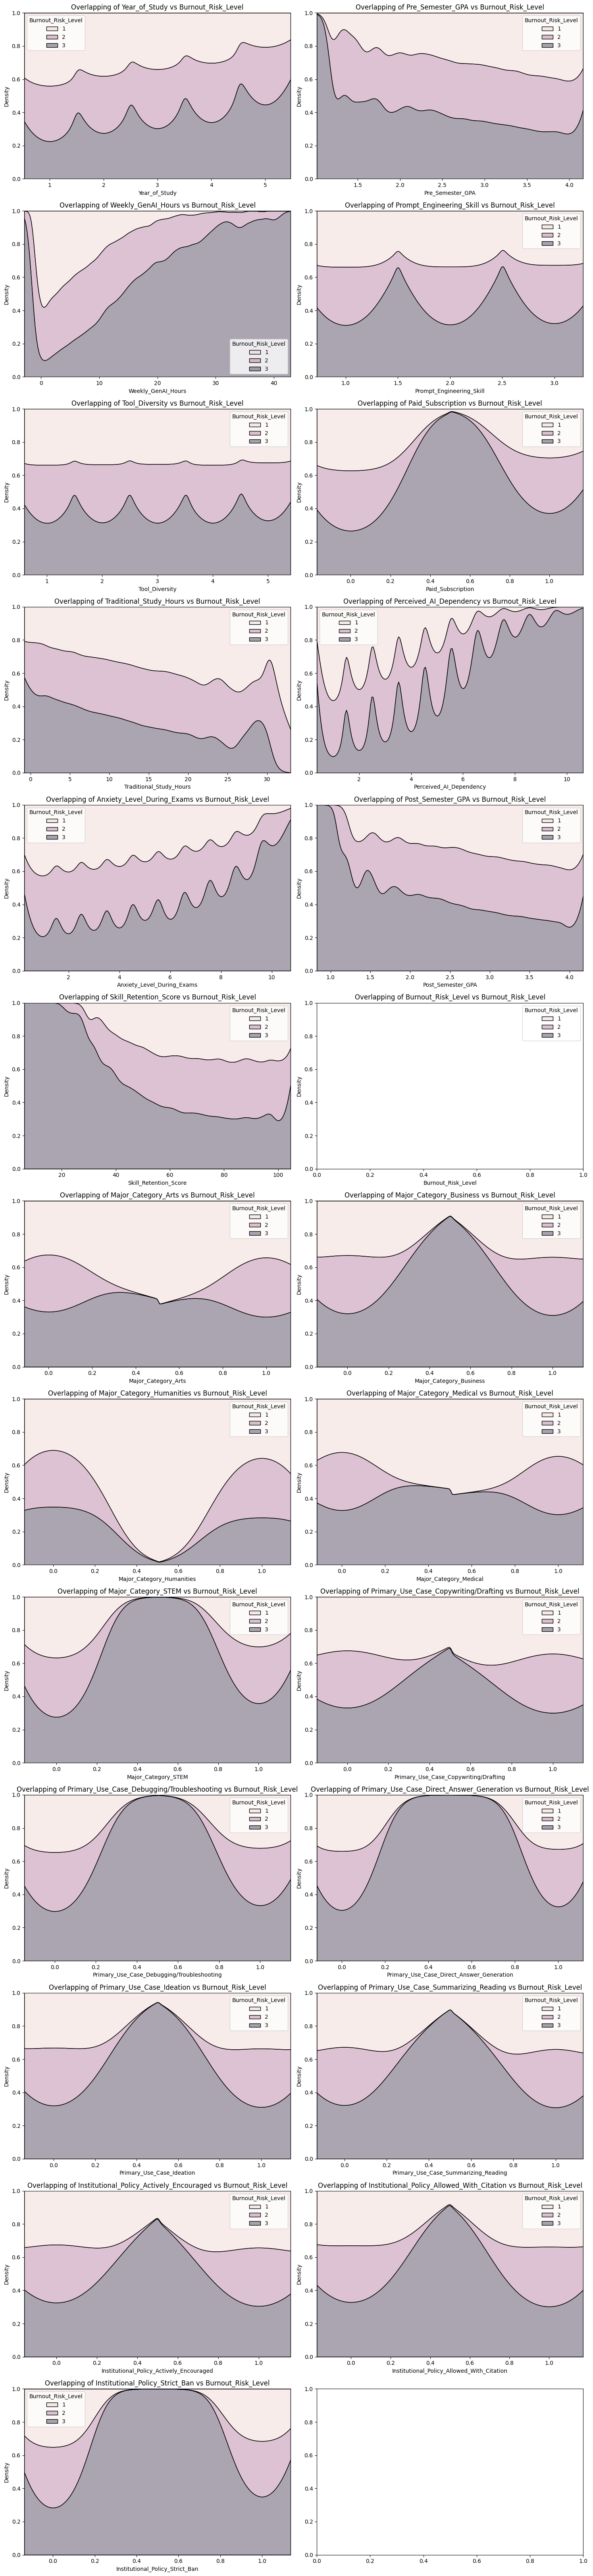

In [31]:
fig, ax = plt.subplots(len(new_df.columns)//2+1, 2, figsize=(15, 5*(len(new_df.columns)//2+1)))

for idx,col in enumerate(new_df.columns):
    sns.kdeplot(
        data=new_df,
        x=col,
        hue="Burnout_Risk_Level",
        ax=ax[idx//2, idx%2],
        fill=True,
        common_norm= False,
        alpha=0.4,
        multiple="fill"
    )
    ax[idx//2, idx%2].set_title(f'Overlapping of {col} vs Burnout_Risk_Level')

plt.tight_layout()
plt.savefig("ai_students_kdeplots_dv_burnout_risk_level.pdf")
plt.show();

In [32]:
copy2 = new_df.copy()
copy2.columns

Index(['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Major_Category_Arts',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban'],
      dtype='object')

In [33]:
corr_matrix.Burnout_Risk_Level

Year_of_Study                                 0.16
Pre_Semester_GPA                             -0.10
Weekly_GenAI_Hours                            0.47
Prompt_Engineering_Skill                      0.01
Tool_Diversity                                0.01
Paid_Subscription                             0.10
Traditional_Study_Hours                      -0.14
Perceived_AI_Dependency                       0.37
Anxiety_Level_During_Exams                    0.16
Post_Semester_GPA                            -0.10
Skill_Retention_Score                        -0.06
Burnout_Risk_Level                            1.00
Major_Category_Arts                          -0.02
Major_Category_Business                      -0.01
Major_Category_Humanities                    -0.05
Major_Category_Medical                       -0.02
Major_Category_STEM                           0.08
Primary_Use_Case_Copywriting/Drafting        -0.02
Primary_Use_Case_Debugging/Troubleshooting    0.03
Primary_Use_Case_Direct_Answer_

In [47]:
copy2 = new_df.drop(columns = ["Major_Category_Arts", "Primary_Use_Case_Ideation", 'Institutional_Policy_Actively_Encouraged'])

In [48]:
copy2["AI_Engagement"] = (
    copy2["Weekly_GenAI_Hours"] *
    copy2["Tool_Diversity"] *
    copy2["Prompt_Engineering_Skill"])

copy2["AI_Dependency_Ratio"] = (
    copy2["Weekly_GenAI_Hours"] /
    (copy2["Traditional_Study_Hours"] + 1)
)

copy2["Total_Study"] = (
    copy2["Weekly_GenAI_Hours"] +
    copy2["Traditional_Study_Hours"]
)

copy2["GPA_Change"] = (
    copy2["Post_Semester_GPA"] -
    copy2["Pre_Semester_GPA"]
)

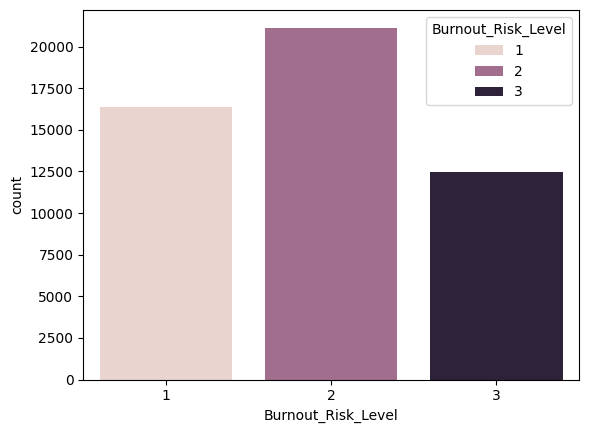

In [49]:
sns.countplot(data= copy2, x = "Burnout_Risk_Level", hue= cls_target)
plt.show();

In [122]:
predictors = [ 
              'Anxiety_Level_During_Exams',
              'Year_of_Study', 'Tool_Diversity',
              "AI_Engagement", "AI_Dependency_Ratio",
              "Total_Study", 'Perceived_AI_Dependency', "Pre_Semester_GPA"]
train_data = copy2[predictors]

target_data = copy2[cls_target]

In [123]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(train_data)
scaled_data = pd.DataFrame(
    scaled_data,
    columns = train_data.columns,
    index = train_data.index
)

In [124]:
X = sm.add_constant(train_data)
VIF = pd.DataFrame()

VIF['Features'] = X.columns
VIF['VIF'] = [vif(X.values, i) for i in range(X.shape[1])]
VIF.sort_values(by = 'VIF', ascending = True)

,Features,VIF
8,Pre_Semester_GPA,1.000131
2,Year_of_Study,1.000162
1,Anxiety_Level_During_Exams,1.111341
5,AI_Dependency_Ratio,1.502637
3,Tool_Diversity,1.526663
7,Perceived_AI_Dependency,1.707029
6,Total_Study,1.952340
4,AI_Engagement,2.694725
0,const,69.215671


In [125]:
x_train, x_test, y_train, y_test = train_test_split(scaled_data, target_data, stratify= target_data, test_size = 0.4, random_state = 26)

In [127]:
x_train_sm = sm.add_constant(x_train)
log_model = sm.MNLogit(y_train.astype('category'), x_train_sm).fit()
log_model.summary()

Optimization terminated successfully.
         Current function value: 0.930172
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:     Burnout_Risk_Level   No. Observations:                29999
Model:                        MNLogit   Df Residuals:                    29981
Method:                           MLE   Df Model:                           16
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.1355
Time:                        23:25:47   Log-Likelihood:                -27904.
converged:                       True   LL-Null:                       -32279.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
      Burnout_Risk_Level=2       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.5846      0.017     33.452      0.000       0.550       0.619
Anxiety_Level_During_Exams     0.0201      0.015      1.337      0.181      -0.009       0.050
Year_of_Study                  0.2844      0.014     20.032      0.000       0.257       0.312
Tool_Diversity                -0.0694      0.018     -3.936      0.000      -0.104      -0.035
AI_Engagement                  0.3285      0.039      8.450      0.000       0.252       0.405
AI_Dependency_Ratio            0.6409      0.044     14.660      0.000       0.555       0.727
Total_Study                    0.0838      0.022      3.881      0.000       0.041       0.126
Perceived_AI_Dependency        0.2106      0.019     11.017      0.000       0.173       0.248
Pre_Semester_GPA              -0.1821      0.014    -12.800      0.000      -0.210      -0.154
----------------------------------------------------------------------------------------------
      Burnout_Risk_Level=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -0.2228      0.021    -10.749      0.000      -0.263      -0.182
Anxiety_Level_During_Exams     0.1151      0.019      6.155      0.000       0.078       0.152
Year_of_Study                  0.5764      0.018     31.422      0.000       0.540       0.612
Tool_Diversity                -0.1971      0.024     -8.286      0.000      -0.244      -0.150
AI_Engagement                  0.5451      0.042     12.984      0.000       0.463       0.627
AI_Dependency_Ratio            0.9755      0.045     21.575      0.000       0.887       1.064
Total_Study                    0.3948      0.026     15.147      0.000       0.344       0.446
Perceived_AI_Dependency        0.5110      0.024     21.416      0.000       0.464       0.558
Pre_Semester_GPA              -0.3402      0.018    -19.062      0.000      -0.375      -0.305
==============================================================================================
"""

In [128]:
np.exp(log_model.params) #log odds

,0,1
const,1.794310,0.800263
Anxiety_Level_During_Exams,1.020296,1.121988
Year_of_Study,1.328942,1.779703
Tool_Diversity,0.932957,0.821132
AI_Engagement,1.388914,1.724855
AI_Dependency_Ratio,1.898167,2.652504
Total_Study,1.087445,1.484032
Perceived_AI_Dependency,1.234375,1.666955
Pre_Semester_GPA,0.833492,0.711644


In [129]:
y_prob = log_model.predict(sm.add_constant(x_test))
y_pred = np.argmax(y_prob.values, axis=1) + 1

In [130]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

0.52775
              precision    recall  f1-score   support

           1       0.53      0.48      0.51      6547
           2       0.48      0.62      0.54      8458
           3       0.68      0.44      0.53      4995

    accuracy                           0.53     20000
   macro avg       0.56      0.51      0.53     20000
weighted avg       0.55      0.53      0.53     20000

[[3151 3244  152]
 [2345 5227  886]
 [ 396 2422 2177]]


In [120]:
tree_model = DecisionTreeClassifier(criterion= 'log_loss', max_depth= 6, min_samples_leaf= 3)
tree_model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [121]:
y_pred = tree_model.predict(x_test)
print(y_pred)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

[1 1 2 ... 3 1 2]
0.5137
              precision    recall  f1-score   support

           1       0.50      0.55      0.52      6547
           2       0.47      0.53      0.50      8458
           3       0.64      0.45      0.53      4995

    accuracy                           0.51     20000
   macro avg       0.54      0.51      0.52     20000
weighted avg       0.53      0.51      0.51     20000

[[3587 2742  218]
 [2990 4452 1016]
 [ 570 2190 2235]]


[[3065 3334  148]
 [2336 5245  877]
 [ 399 2440 2156]]

In [61]:
copy2.Burnout_Risk_Level.value_counts()

Burnout_Risk_Level
2    21144
1    16368
3    12487
Name: count, dtype: int64

In [66]:
print(tree_model.score(x_train, y_train))
print(tree_model.score(x_test, y_test))

0.525584186139538
0.51345


In [65]:
copy2["Burnout_Risk_Level"].value_counts(normalize=True)

Burnout_Risk_Level
2    0.422888
1    0.327367
3    0.249745
Name: proportion, dtype: float64

In [67]:
copy2.columns

Index(['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level',
       'Major_Category_Business', 'Major_Category_Humanities',
       'Major_Category_Medical', 'Major_Category_STEM',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Summarizing_Reading',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban', 'AI_Engagement',
       'AI_Dependency_Ratio', 'Total_Study', 'GPA_Change'],
      dtype='object')

In [69]:
data  =  scaler.fit_transform(copy2[['Pre_Semester_GPA', 'AI_Engagement', 'AI_Dependency_Ratio', 'Total_Study', 'Primary_Use_Case_Copywriting/Drafting', 'Anxiety_Level_During_Exams']])
new_trgt = copy2.Post_Semester_GPA

x_train, x_test, y_train, y_test = train_test_split(scaled_data, target_data, stratify= target_data, test_size = 0.4, random_state = 26)

In [71]:
lin_model = sm.OLS(y_train, sm.add_constant(x_train)).fit(cov_type= 'HC3')
lin_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Burnout_Risk_Level   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     1527.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:25:24   Log-Likelihood:                -30607.
No. Observations:               29999   AIC:                         6.123e+04
Df Residuals:                   29992   BIC:                         6.129e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.9218      0.004    495.729      0.000       1.914       1.929
Anxiety_Level_During_Exams     0.0469      0.004     11.767      0.000       0.039       0.055
Year_of_Study                  0.1239      0.004     32.091      0.000       0.116       0.131
Tool_Diversity                -0.0498      0.005    -10.439      0.000      -0.059      -0.040
AI_Engagement                  0.1204      0.006     20.936      0.000       0.109       0.132
AI_Dependency_Ratio            0.1335      0.005     26.296      0.000       0.124       0.143
Total_Study                    0.1364      0.005     27.729      0.000       0.127       0.146
==============================================================================
Omnibus:                     2882.937   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              954.183
Skew:                           0.155   Prob(JB):                    6.34e-208
Kurtosis:                       2.183   Cond. No.                         3.05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""